# Mountains vs. Beaches Preference Classification

The goal is to predict whether a person prefers a **beach** (0) or a **mountain** (1) vacation from
demographic and lifestyle features, using three classifiers, comparing them with cross-validation,
guarding against overfitting, and then trying to improve the scores.

## Step 1: Choice of three classifiers

From the available options (Decision Trees, Naive Bayes, Neural Networks, K-Nearest Neighbours, SVM)
this project uses:

1. **Decision Tree** - a white-box model that handles the mixed numeric/categorical features
   directly and reports feature importances, which is exactly what we need to *analyse the features
   that influence the preference*.
2. **K-Nearest Neighbours** - a simple, non-parametric, instance-based baseline that makes no
   assumptions about the decision boundary; it is sensitive to feature scaling and dimensionality,
   so it is a useful contrast to the other two.
3. **Neural Network (MLP)** - a flexible, high-capacity non-linear model that represents the modern
   approach and lets us check whether extra capacity beats a simple tree on this data.

(SVM was set aside because a kernel SVM scales roughly quadratically with the 52,000 samples here,
which is impractical, whereas the three chosen models all train quickly.)

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
sns.set_style("whitegrid")
RS = 42

## Data exploration

In [2]:
df = pd.read_csv("mountains_vs_beaches_preferences.csv")
print("Shape:", df.shape)
print("Target balance (0 = beach, 1 = mountain):")
print(df["Preference"].value_counts(normalize=True).round(3))
df.head()

Shape: (52444, 14)
Target balance (0 = beach, 1 = mountain):
Preference
0    0.749
1    0.251
Name: proportion, dtype: float64


,Age,Gender,Income,Education_Level,Travel_Frequency,Preferred_Activities,Vacation_Budget,Location,Proximity_to_Mountains,Proximity_to_Beaches,Favorite_Season,Pets,Environmental_Concerns,Preference
0,56,male,71477,bachelor,9,skiing,2477,urban,175,267,summer,0,1,1
1,69,male,88740,master,1,swimming,4777,suburban,228,190,fall,0,1,0
2,46,female,46562,master,0,skiing,1469,urban,71,280,winter,0,0,1
3,32,non-binary,99044,high school,6,hiking,1482,rural,31,255,summer,1,0,1
4,60,female,106583,high school,5,sunbathing,516,suburban,23,151,winter,1,1,0


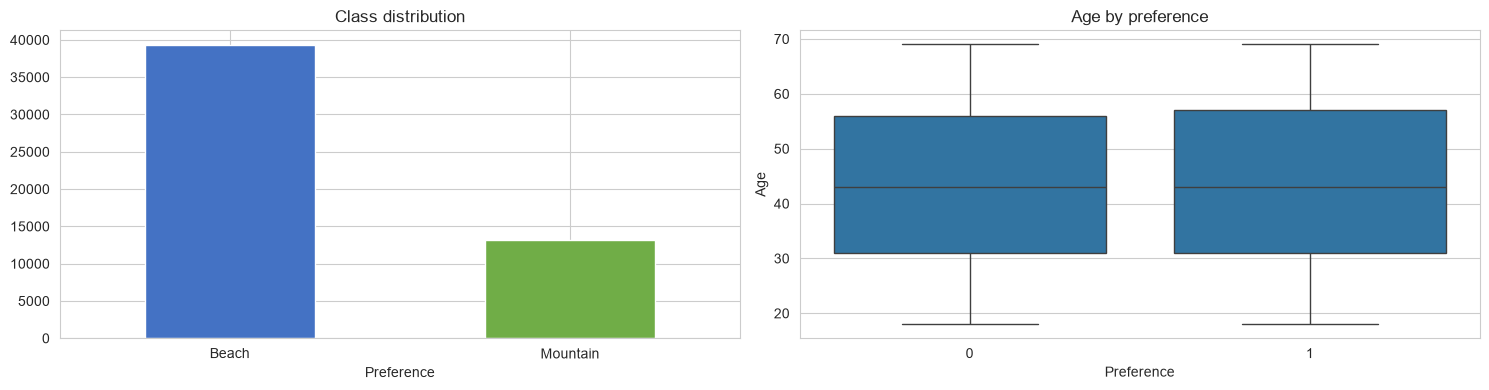

,Age,Income,Travel_Frequency,Vacation_Budget,Proximity_to_Mountains,Proximity_to_Beaches,Pets,Environmental_Concerns,Preference
count,52444.0,52444.0,52444.0,52444.0,52444.0,52444.0,52444.0,52444.0,52444.0
mean,43.5,70017.3,4.5,2741.8,149.9,149.9,0.5,0.5,0.3
std,15.0,28847.6,2.9,1296.9,86.5,86.5,0.5,0.5,0.4
min,18.0,20001.0,0.0,500.0,0.0,0.0,0.0,0.0,0.0
25%,31.0,45048.2,2.0,1622.0,75.0,75.8,0.0,0.0,0.0
50%,43.0,70167.0,4.0,2733.0,150.0,150.0,1.0,0.0,0.0
75%,56.0,95108.5,7.0,3869.0,225.0,225.0,1.0,1.0,1.0
max,69.0,119999.0,9.0,4999.0,299.0,299.0,1.0,1.0,1.0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
df["Preference"].map({0: "Beach", 1: "Mountain"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#4472C4", "#70AD47"])
axes[0].set_title("Class distribution"); axes[0].tick_params(axis="x", rotation=0)
sns.boxplot(data=df, x="Preference", y="Age", ax=axes[1]); axes[1].set_title("Age by preference")
plt.tight_layout(); plt.show()
df.describe().round(1)

The target is **imbalanced**: about 75% of people prefer beaches and 25% prefer mountains. Because
of that imbalance we report precision, recall and F1 for the mountain class in addition to accuracy.

## Preprocessing and train/test split

The five categorical columns are one-hot encoded and the numeric columns are standardised, all inside
a `ColumnTransformer` so the transformation is fit on the training data only. This is the only
transformation applied to the dataset. The data is split 80% / 20% with stratification on the target.

In [4]:
y = df["Preference"]
X = df.drop(columns="Preference")
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RS, stratify=y)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Train: (41955, 13) | Test: (10489, 13)
Categorical: ['Gender', 'Education_Level', 'Preferred_Activities', 'Location', 'Favorite_Season']
Numeric: ['Age', 'Income', 'Travel_Frequency', 'Vacation_Budget', 'Proximity_to_Mountains', 'Proximity_to_Beaches', 'Pets', 'Environmental_Concerns']


## Step 2: Train, validate and compare the three classifiers

Each model is wrapped in a pipeline with the preprocessor and assessed with **10-fold stratified
cross-validation** on the training set , then evaluated
once on the held-out test set.

In [5]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RS),
    "KNN":           KNeighborsClassifier(),
    "Neural Net (MLP)": MLPClassifier(hidden_layer_sizes=(64,), max_iter=150, random_state=RS),
}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RS)

rows, conf = [], {}
for name, clf in models.items():
    pipe = Pipeline([("pre", preprocess), ("clf", clf)])
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    conf[name] = confusion_matrix(y_test, pred)
    rows.append({"Model": name,
                 "CV acc (mean)": round(cv_acc.mean(), 4),
                 "CV acc (std)": round(cv_acc.std(), 4),
                 "Test acc": round(accuracy_score(y_test, pred), 4),
                 "Test precision": round(precision_score(y_test, pred), 4),
                 "Test recall": round(recall_score(y_test, pred), 4),
                 "Test F1": round(f1_score(y_test, pred), 4)})
results = pd.DataFrame(rows)
results

,Model,CV acc (mean),CV acc (std),Test acc,Test precision,Test recall,Test F1
0,Decision Tree,0.9949,0.0012,0.9961,0.9928,0.9916,0.9922
1,KNN,0.9231,0.0043,0.9204,0.8887,0.7802,0.8309
2,Neural Net (MLP),0.9980,0.0004,0.9982,0.9985,0.9943,0.9964


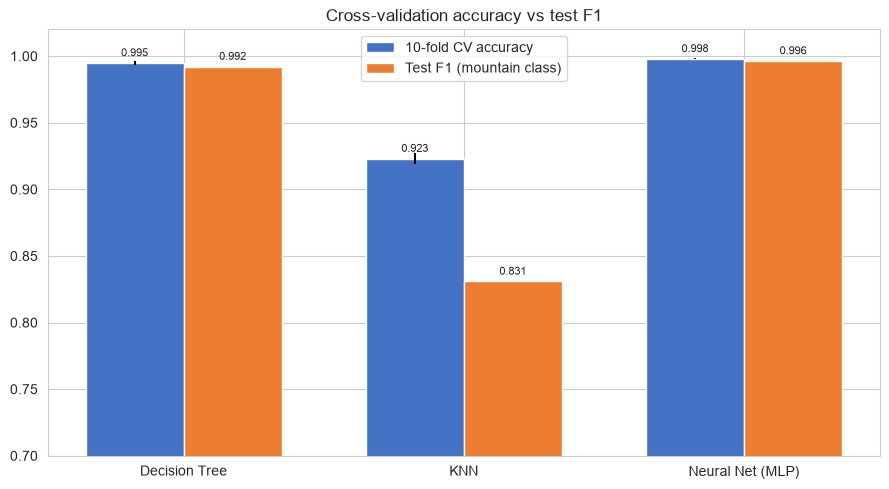

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results)); w = 0.35
ax.bar(x - w/2, results["CV acc (mean)"], w, yerr=results["CV acc (std)"], label="10-fold CV accuracy", color="#4472C4")
ax.bar(x + w/2, results["Test F1"], w, label="Test F1 (mountain class)", color="#ED7D31")
ax.set_xticks(x); ax.set_xticklabels(results["Model"]); ax.set_ylim(0.7, 1.02)
ax.set_title("Cross-validation accuracy vs test F1"); ax.legend()
for i, r in results.iterrows():
    ax.text(i - w/2, r["CV acc (mean)"] + 0.005, f"{r['CV acc (mean)']:.3f}", ha="center", fontsize=8)
    ax.text(i + w/2, r["Test F1"] + 0.005, f"{r['Test F1']:.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

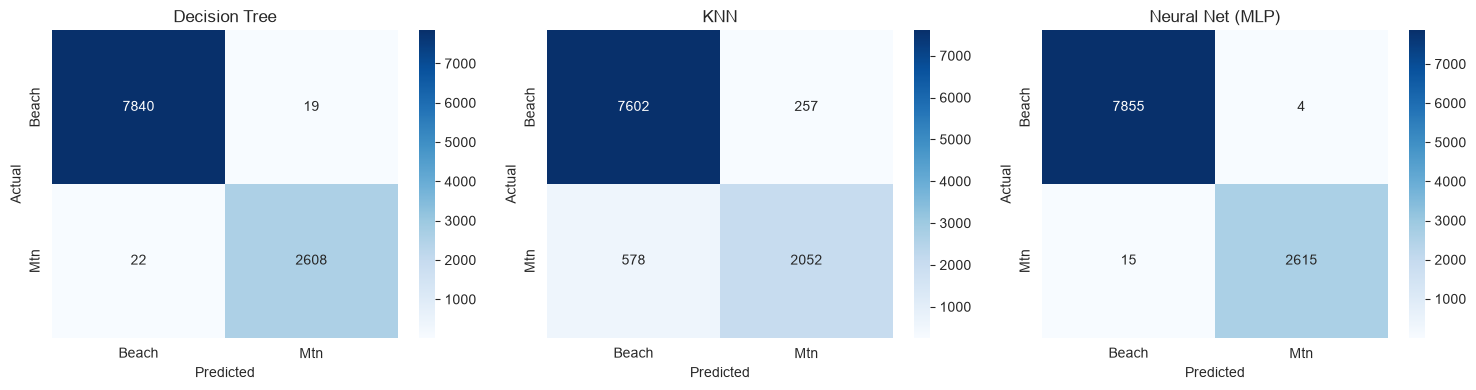

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, cm) in zip(axes, conf.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Beach", "Mtn"], yticklabels=["Beach", "Mtn"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

### Overfitting check

The fully grown decision tree fits the training data perfectly, so we plot training vs validation
accuracy against `max_depth` to see where it starts to overfit.

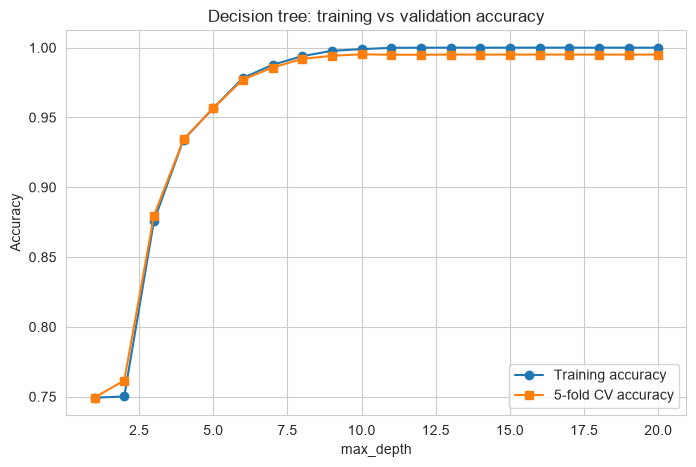

Best max_depth by CV: 10 | CV acc: 0.9952


In [8]:
depths = range(1, 21)
tr_scores, va_scores = [], []
for d in depths:
    pipe = Pipeline([("pre", preprocess), ("clf", DecisionTreeClassifier(max_depth=d, random_state=RS))])
    va = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy").mean()
    pipe.fit(X_train, y_train)
    tr_scores.append(pipe.score(X_train, y_train)); va_scores.append(va)

plt.figure(figsize=(8, 5))
plt.plot(list(depths), tr_scores, marker="o", label="Training accuracy")
plt.plot(list(depths), va_scores, marker="s", label="5-fold CV accuracy")
plt.xlabel("max_depth"); plt.ylabel("Accuracy"); plt.title("Decision tree: training vs validation accuracy")
plt.legend(); plt.show()
best_depth = list(depths)[int(np.argmax(va_scores))]
print("Best max_depth by CV:", best_depth, "| CV acc:", round(max(va_scores), 4))

**Observation.** The unrestricted tree reaches 100% training accuracy while its
cross-validation accuracy is slightly lower, the classic sign of overfitting. The CV accuracy
plateaus at a moderate depth, so a depth-limited tree generalises just as well with far less
complexity. The MLP, in contrast, generalises well without special tuning.

## Step 3: Improving the scores

Two directions: tune the weakest model (KNN) with a grid search, and read the decision tree's
feature importances to understand and confirm what drives the prediction.

In [9]:
knn_grid = GridSearchCV(
    Pipeline([("pre", preprocess), ("clf", KNeighborsClassifier())]),
    {"clf__n_neighbors": [5, 15, 31, 51], "clf__weights": ["uniform", "distance"]},
    cv=5, scoring="f1", n_jobs=1)
knn_grid.fit(X_train, y_train)
knn_pred = knn_grid.predict(X_test)
print("Best KNN params:", knn_grid.best_params_)
print("Tuned KNN  - test acc:", round(accuracy_score(y_test, knn_pred), 4),
      "| test F1:", round(f1_score(y_test, knn_pred), 4))
print("(baseline KNN test F1 was", round(results.loc[results.Model=='KNN','Test F1'].iloc[0], 4), ")")

Best KNN params: {'clf__n_neighbors': 15, 'clf__weights': 'distance'}
Tuned KNN  - test acc: 0.9388 | test F1: 0.8654
(baseline KNN test F1 was 0.8309 )


Depth-limited tree (max_depth=10) - test acc: 0.9962 | test F1: 0.9924


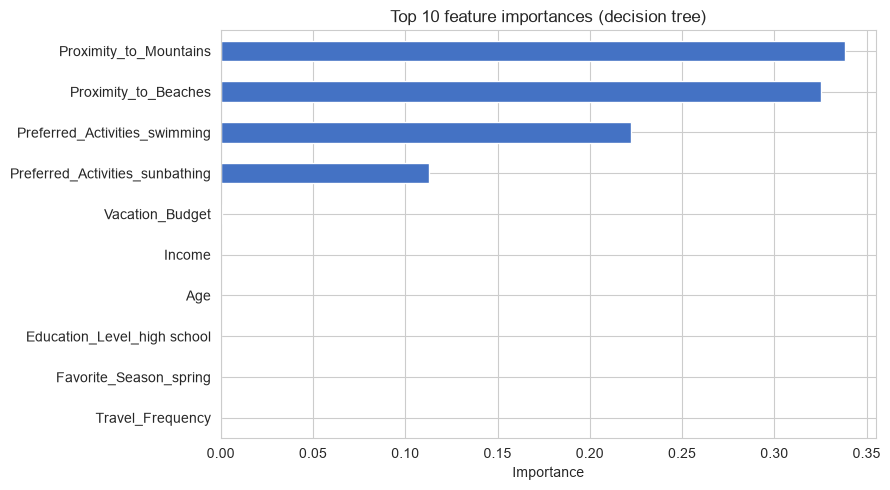

Most influential features:
 Proximity_to_Mountains             0.338
Proximity_to_Beaches               0.325
Preferred_Activities_swimming      0.222
Preferred_Activities_sunbathing    0.113
Vacation_Budget                    0.000
Income                             0.000
Age                                0.000
Education_Level_high school        0.000
Favorite_Season_spring             0.000
Travel_Frequency                   0.000
dtype: float64


In [10]:
# tuned, depth-limited decision tree
dt_best = Pipeline([("pre", preprocess),
                    ("clf", DecisionTreeClassifier(max_depth=best_depth, random_state=RS))]).fit(X_train, y_train)
dt_pred = dt_best.predict(X_test)
print(f"Depth-limited tree (max_depth={best_depth}) - test acc:",
      round(accuracy_score(y_test, dt_pred), 4), "| test F1:", round(f1_score(y_test, dt_pred), 4))

# feature importances from the tree
ohe = dt_best.named_steps["pre"].named_transformers_["cat"]
feat_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
importances = pd.Series(dt_best.named_steps["clf"].feature_importances_, index=feat_names)
top = importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 5))
top[::-1].plot(kind="barh", color="#4472C4")
plt.title("Top 10 feature importances (decision tree)"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()
print("Most influential features:\n", top.round(3))

**Discussion.** Tuning KNN (more neighbours and distance weighting) raises its F1 noticeably,
closing much of the gap to the tree and the network, which confirms that KNN's weakness was the
choice of `k` rather than the data being hard. The decision tree and MLP were already close to the
ceiling, so the main gain there is from controlling depth to remove the overfitting without losing
accuracy. The feature-importance chart shows that a small number of features dominate the
preference, which is why even a shallow tree classifies almost perfectly.

## Step 4: Conclusion

This project built and compared three classifiers for the beach-vs-mountain preference task.
The decision tree and the neural network both reached very high accuracy and F1, while a default KNN
lagged behind until its neighbourhood size was tuned. Using 10-fold cross-validation kept the model
comparison honest, and the training-vs-validation curve showed where the tree began to overfit, which
a depth limit then fixed.

**What was achieved.** Three working, validated classifiers, a fair cross-validated comparison, an
explicit overfitting analysis, an improvement step that tuned the weakest model, and a feature
analysis identifying the variables that drive the preference.

**Drawbacks.** The dataset is large but heavily imbalanced (about 75/25), so accuracy alone is
misleading and we relied on F1 for the minority class. The very high scores suggest the data is
strongly separable (possibly close to synthetic), so the task is easier than a real-world preference
problem would be.

**Possible improvements.** Resampling or class weights for the imbalance, an ensemble such as a random
forest or gradient boosting, calibrated probabilities, and a richer hyperparameter search would be the
natural next steps, though the headroom is small given the scores are already near the ceiling.